In [1]:
import numpy as np
import pandas as pd
from utils import plot_training_metrics
from stable_baselines3 import PPO
from liquidation_env import rawDLVEnv

In [2]:

nect_df = pd.read_csv('datas/nect_honey_price.csv')
island_df = pd.read_csv('datas/island_data.csv')

nect_price = nect_df['price'].values
nav = island_df['nav'].values
volatile_part = island_df['wbtc_frac'].values

timestamp = nect_df['timestamp'].values

SCALE = 6.5*10**7
nav = nav/SCALE

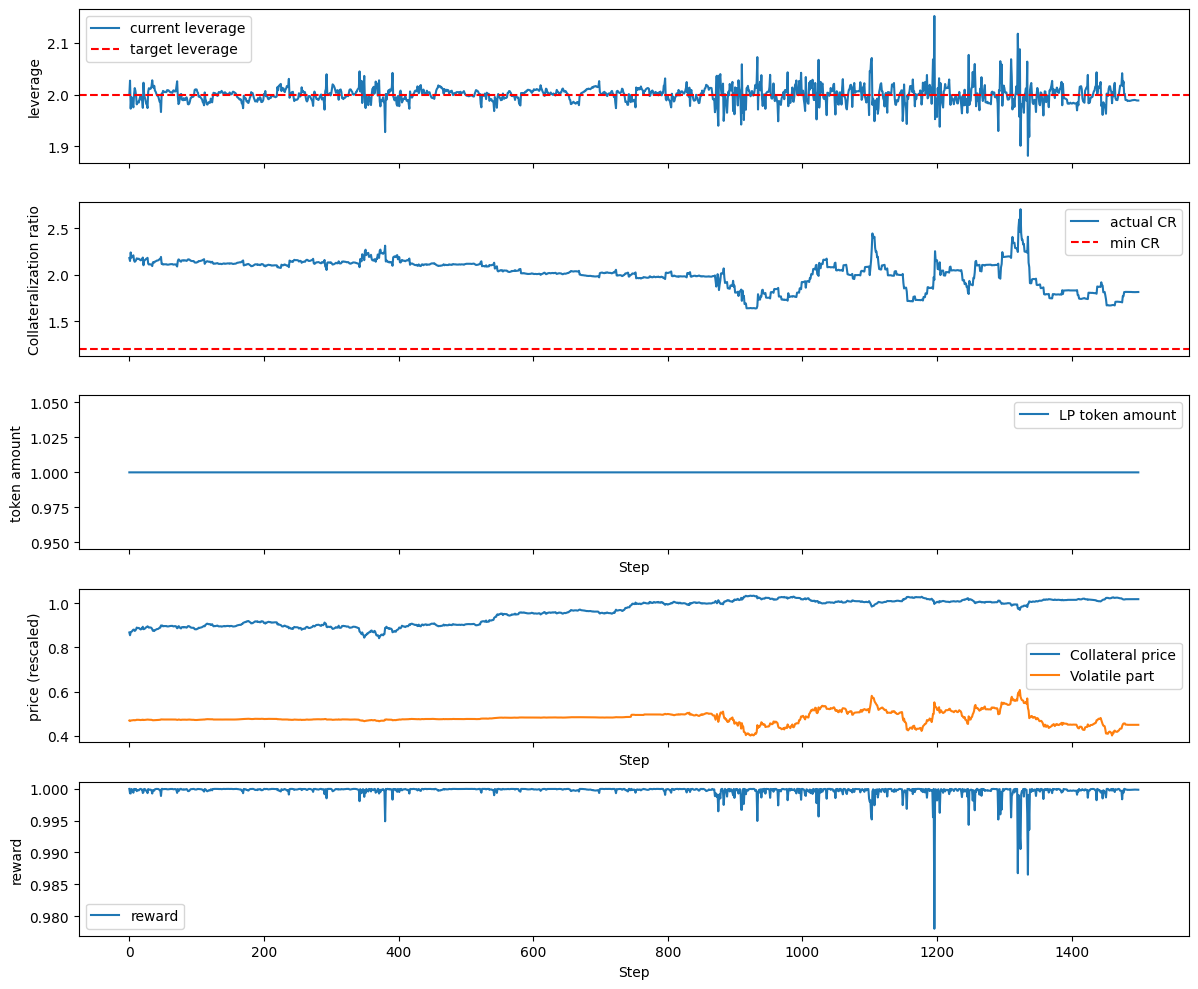

In [3]:
def naiveAgent(obs, target_leverage = 2, max_step = 0.15):

    nect = obs[0]
    leverage = obs[3]+2
    colateral_value = obs[1]
    volatile_part_value = obs[2]

    if abs(leverage - target_leverage)/target_leverage<=0.01:
        return [0]
    else: 
        nect_target = (target_leverage - 1)*(colateral_value - volatile_part_value)
        return [(nect_target-nect)/max_step]
    
env = rawDLVEnv(nect_honey_price=nect_price, LP_nav_honey=nav, volatile_part=volatile_part)

obs, _ = env.reset()

done = False
while not done:
    action = naiveAgent(obs)  
    obs, reward, _, done, _ = env.step(action)

agent_history = env.history
plot_training_metrics(agent_history)

In [4]:
train_env = rawDLVEnv(
    nect_honey_price=nect_price, 
    LP_nav_honey=nav, 
    volatile_part=volatile_part,
    is_training=True
)

model = PPO(
    "MlpPolicy", 
    train_env, 
    verbose=1
)
model.learn(total_timesteps=150000)
#model.save("ppo_leverage_historical")

_, num_of_liquidation = train_env.get_history()
print('Liquidations during learnings:', num_of_liquidation)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1.5e+03   |
|    ep_rew_mean     | -5.88e+04 |
| time/              |           |
|    fps             | 2989      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.5e+03     |
|    ep_rew_mean          | -3.91e+04   |
| time/                   |             |
|    fps                  | 1950        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006260978 |
|    clip_fraction        | 0.0583      |
|    clip_range           | 0.2         |
|    entro

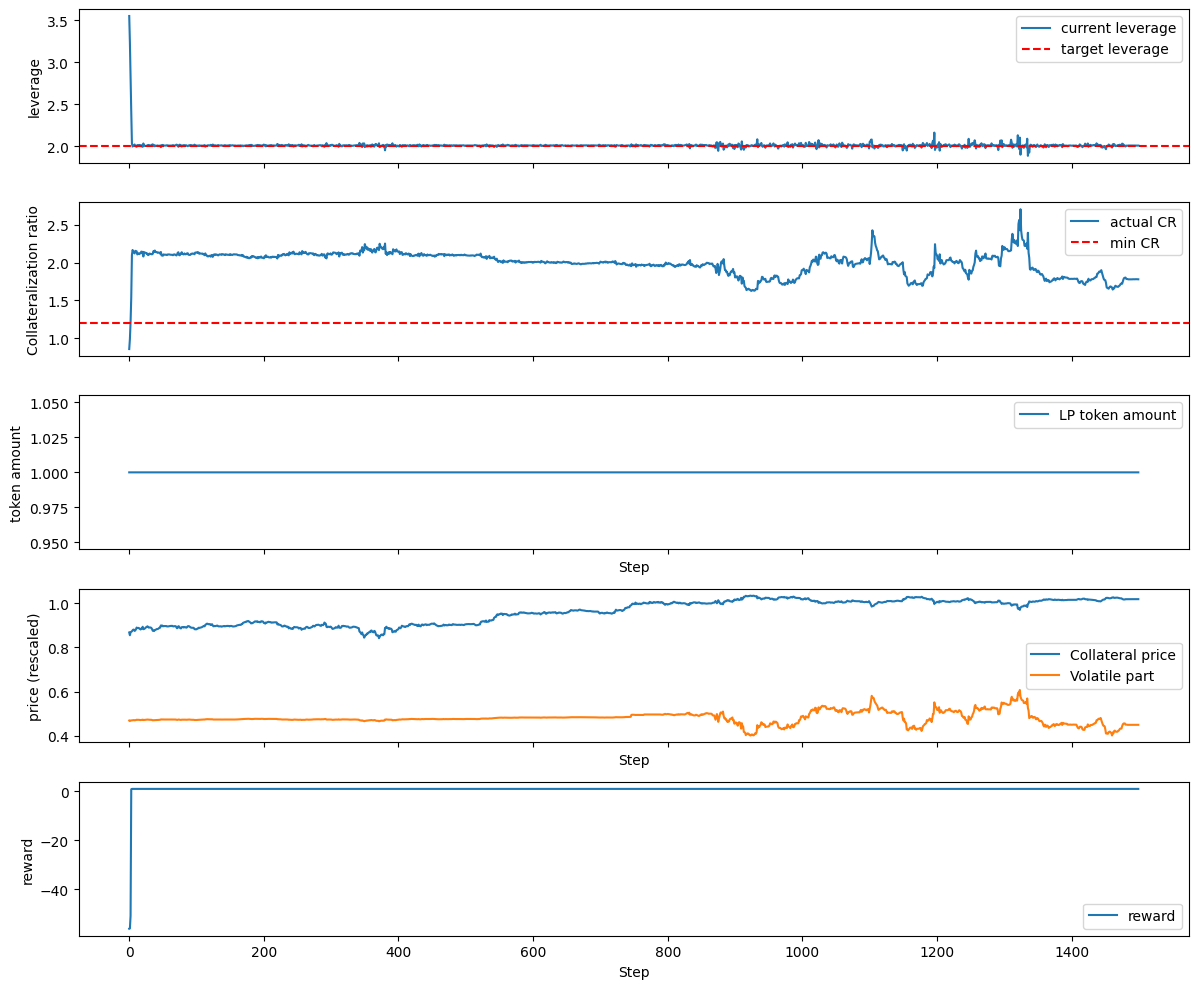

In [11]:
eval_env = rawDLVEnv(
    nect_honey_price=nect_price, 
    LP_nav_honey=nav, 
    volatile_part=volatile_part,
    is_training=True
)

obs, _ = eval_env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, _, done, _ = eval_env.step(action)

history, _ = eval_env.get_history()
plot_training_metrics(history)

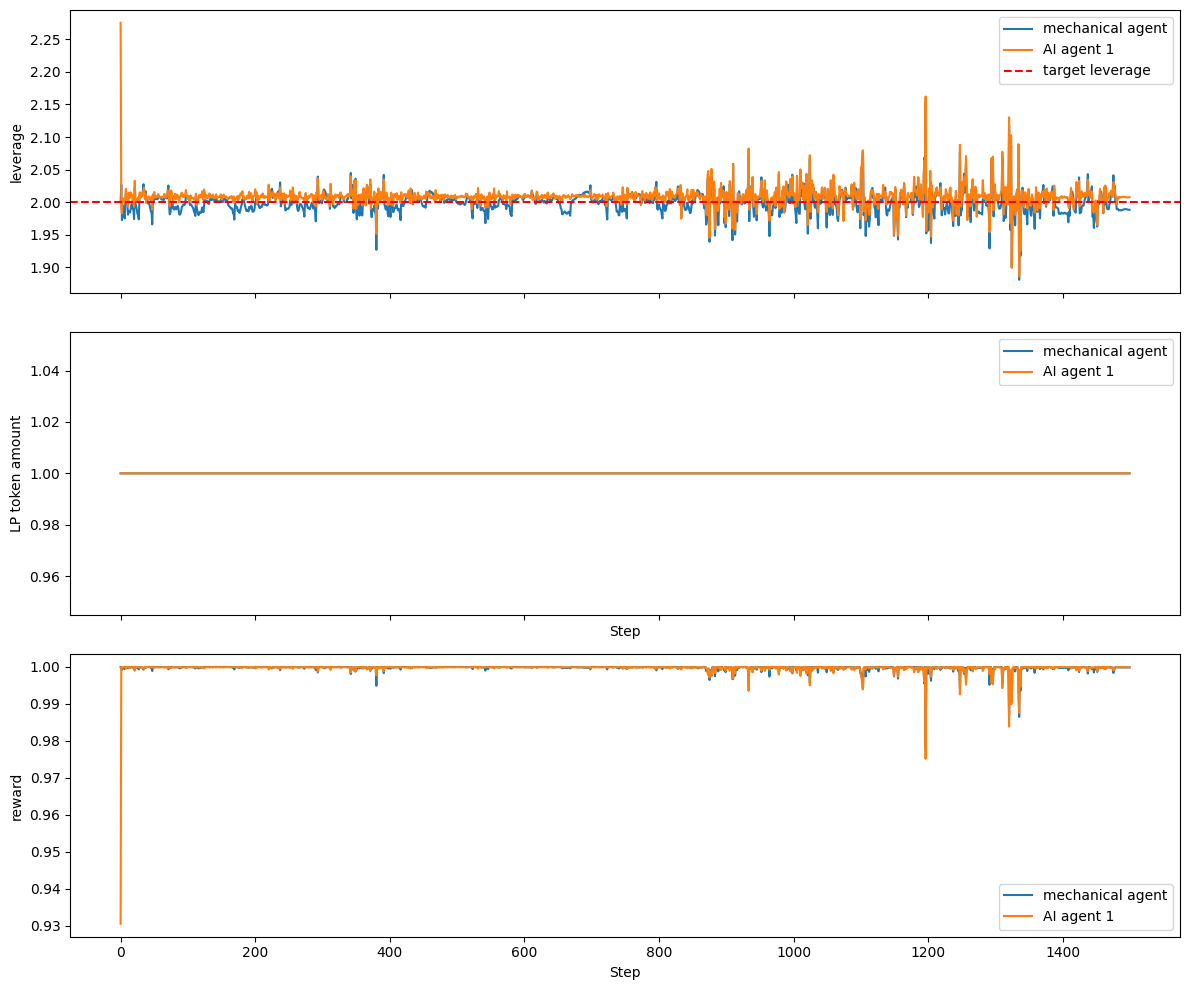

In [6]:
from utils import plot_training_comparison

plot_training_comparison(agent_history, [history])